### Calculating the board

In [342]:
from ultralytics import YOLO
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [343]:
model_board = YOLO("../code/runs/segment/train6/weights/best.pt")

In [344]:
test_image_path = "../code/captured_images/image_94.jpg"

In [345]:
result = model_board.predict(test_image_path,retina_masks=True)


image 1/1 f:\Chess\code\..\code\captured_images\image_94.jpg: 480x640 1 Board, 1 White_start, 6.5ms
Speed: 0.6ms preprocess, 6.5ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)


In [346]:
result[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'Board', 1: 'White_start'}
obb: None
orig_img: array([[[161, 179, 190],
        [161, 179, 190],
        [162, 180, 191],
        ...,
        [215, 215, 215],
        [213, 216, 214],
        [213, 216, 214]],

       [[161, 179, 190],
        [161, 179, 190],
        [161, 179, 190],
        ...,
        [214, 214, 214],
        [212, 215, 213],
        [211, 214, 212]],

       [[161, 178, 191],
        [161, 178, 191],
        [160, 179, 192],
        ...,
        [214, 214, 214],
        [213, 213, 213],
        [212, 212, 212]],

       ...,

       [[ 20,  39,  42],
        [ 22,  41,  44],
        [ 16,  33,  36],
        ...,
        [ 83,  52,  27],
        [ 84,  52,  23],
        [ 78,  47,  16]],

       [[ 16,  32,  38],
        [ 21,  37,  43],
        [ 39,  54,  57],
        ...,
        [ 5

[[        275         423]
 [        486         275]
 [        347          33]
 [        124         155]]


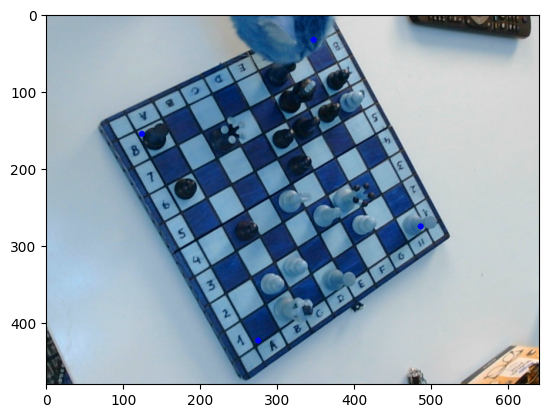

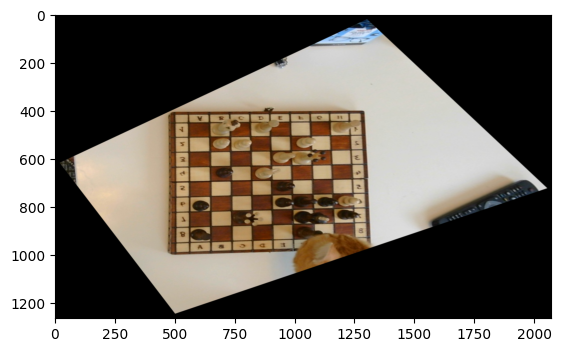

In [347]:
def harris_corners(img, max_corners=4):

    """
    For finding the corners of the board for homography.
    Uses harris corner detector and then uses sort_corners
    before returning it as numpy array.
    Defaults to returning 4 corners.

    """


    # Harris response
    harris = cv2.cornerHarris(img, 15, 15, 0.04)
    harris = cv2.dilate(harris, None)

    # Normalize to 0–255 so goodFeaturesToTrack can use it
    harris_norm = cv2.normalize(harris, None, 0, 255, cv2.NORM_MINMAX)
    harris_norm = np.uint8(harris_norm)

    corners = cv2.goodFeaturesToTrack(
        harris_norm,
        maxCorners=max_corners,
        qualityLevel=0.01,
        minDistance=60
    )

    corners = np.array([tuple(pt.ravel()) for pt in corners])
    corners = sort_corners(corners)


    if corners is None:
        Exception("No corners")

    return corners

def plot_corners(img, corners, radius=4, color=(0,0,255), thickness=-1):
    """
    Debugging function

    img: input image (grayscale or BGR)
    corners: list of (x, y) tuples
    """
    # Convert grayscale to BGR so colored dots show up
    if len(img.shape) == 2:
        img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        img_color = img.copy()

    for (x, y) in corners:
        cv2.circle(img_color, (int(x), int(y)), radius, color, thickness)

    return img_color

import numpy as np

def sort_corners(corners):
    """
    Sorts the corners from harris detector
    corners: list or array of 4 (x, y) points
    returns: array of points ordered as:
             top-left, top-right, bottom-right, bottom-left
    """

    pts = np.array(corners, dtype=np.float32)

    # Step 1: sort by y (top to bottom)
    pts = pts[np.argsort(pts[:,1])]

    # First two are top, last two are bottom
    top = pts[:2]
    bottom = pts[2:]

    # Step 2: sort left-to-right within each row
    top = top[np.argsort(top[:,0])]
    bottom = bottom[np.argsort(bottom[:,0])]

    # Order: TL, TR, BR, BL
    ordered = np.array([bottom[0],bottom[1], top[1], top[0]], dtype=np.float32)
    return ordered


def calculate_homography(result):
    """
        Calculate and return the homography for BEV
        based on the board mask. Takes in a 
        results object from a YOLO model.
        The corners of a square in an image is points
        that are closest to the edges.
    """
    #This section of the code is to figure out which masks is for which object
    #It assumes only 1 detection for both
    detection_dict = result[0].names
    board_label = [k for k, v in detection_dict.items() if v == "Board"][0]
    white_label = [k for k, v in detection_dict.items() if v == "White_start"][0]
    objects_detected = result[0].boxes.cls
    idx_board = (objects_detected == board_label).nonzero(as_tuple=True)[0][0].item()
    idx_white = (objects_detected == white_label).nonzero(as_tuple=True)[0][0].item()

    #Finding the corners of the board
    board_mask = result[0].masks.xy[idx_board].astype(np.int32)
    image = cv2.imread(test_image_path)
    zeros_img = np.zeros_like(image[:,:,0],dtype=np.uint8)


    mask_boundary = cv2.polylines(zeros_img,     #Create a boundary of the mask
        [board_mask],
        isClosed=True,
        color=255,
        thickness=1
    )


    corners = harris_corners(mask_boundary)
    print(corners)
    plt.imshow(plot_corners(image,corners=corners))
    plt.show()
    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h,w = img.shape[:2]
    bev_pts = np.array([
        [0, 0],                        
        [w, 0],              
        [w, h],    
        [0, h]              
    ], dtype=np.float32).reshape(-1,1,2)

    #TODO: Figure out rotations (Need to translate to origin I think), displaying the board + the text 
    H, _ = cv2.findHomography(corners, bev_pts)
    warped_corners = cv2.perspectiveTransform(bev_pts,H)
    # Apply homography to warp the image into BEV
    xs = warped_corners[:,0,0]
    ys = warped_corners[:,0,1]

    min_x, max_x = int(xs.min()), int(xs.max())
    min_y, max_y = int(ys.min()), int(ys.max())

    pad = 20
    min_x = int(min_x - pad)
    max_x = int(max_x + pad)
    min_y = int(min_y - pad)
    max_y = int(max_y + pad)

    T = np.array([
        [1, 0, -min_x],
        [0, 1, -min_y],
        [0, 0, 1]
    ], dtype=np.float32)

    R90 = np.array([
        [0, -1, 0],
        [1,  0, 0],
        [0,  0, 1]
    ], dtype=np.float32)

    T_origin = np.array([
        [1, 0, -w],
        [0, 1, -h],
        [0, 0, 1]
    ], dtype=np.float32)

    T_from_origin = np.array([
        [1, 0, w],
        [0, 1, h],
        [0, 0, 1]
    ], dtype=np.float32)

    Full_rotation = T_from_origin @ R90 @T_origin

    full_warp = cv2.warpPerspective(
        img,
        T @ H,
        (max_x - min_x, max_y - min_y)
    )


    plt.imshow(full_warp)




calculate_homography(result)


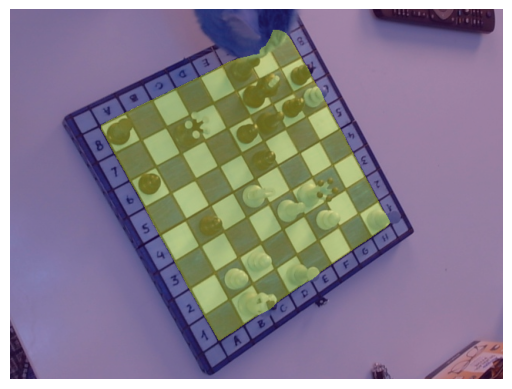

In [349]:

img = result[0].orig_img
mask = result[0].masks.data[1].cpu().numpy()

plt.imshow(img)
plt.imshow(mask, alpha=0.4)  # overlay
plt.axis("off")
plt.show()
